In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/competitions/ieee-fraud-detection/sample_submission.csv
/kaggle/input/competitions/ieee-fraud-detection/test_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/train_identity.csv
/kaggle/input/competitions/ieee-fraud-detection/test_transaction.csv
/kaggle/input/competitions/ieee-fraud-detection/train_transaction.csv


In [3]:
import matplotlib.pyplot as plt
import seaborn as sns
import gc
import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', 100)
plt.rcParams['figure.figsize'] = (12, 5)
sns.set_style('whitegrid')

PATH = "/kaggle/input/competitions/ieee-fraud-detection/"

In [4]:
train_tx = pd.read_csv(PATH + "train_transaction.csv")
train_id = pd.read_csv(PATH + "train_identity.csv")
test_tx  = pd.read_csv(PATH + "test_transaction.csv")
test_id  = pd.read_csv(PATH + "test_identity.csv")

train = train_tx.merge(train_id, on="TransactionID", how="left")
test  = test_tx.merge(test_id,  on="TransactionID", how="left")

print(f"identity rows /transaction rows: {train_id.shape[0] / train_tx.shape[0]:.1%}")

print(f"Total train shape (transaction mergd with identity): {train.shape}")
print(f"Total test shape (transactuion merged with identity):  {test.shape}")


identity rows /transaction rows: 24.4%
Total train shape (transaction mergd with identity): (590540, 434)
Total test shape (transactuion merged with identity):  (506691, 433)


In [5]:
train.head()

,TransactionID,isFraud,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_12,id_13,id_14,id_15,id_16,id_17,id_18,id_19,id_20,id_21,id_22,id_23,id_24,id_25,id_26,id_27,id_28,id_29,id_30,id_31,id_32,id_33,id_34,id_35,id_36,id_37,id_38,DeviceType,DeviceInfo
0,2987000,0,86400,68.5,W,13926,NaN,150.0,discover,142.0,credit,315.0,87.0,19.0,NaN,NaN,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,2.0,0.0,1.0,1.0,14.0,NaN,13.0,NaN,NaN,NaN,NaN,NaN,NaN,13.0,13.0,NaN,NaN,NaN,0.0,T,T,T,M2,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,2987001,0,86401,29.0,W,2755,404.0,150.0,mastercard,102.0,credit,325.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,2987002,0,86469,59.0,W,4663,490.0,150.0,visa,166.0,debit,330.0,87.0,287.0,NaN,outlook.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,0.0,NaN,NaN,NaN,NaN,NaN,0.0,315.0,NaN,NaN,NaN,315.0,T,T,T,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,2987003,0,86499,50.0,W,18132,567.0,150.0,mastercard,117.0,debit,476.0,87.0,NaN,NaN,yahoo.com,NaN,2.0,5.0,0.0,0.0,0.0,4.0,0.0,0.0,1.0,0.0,1.0,0.0,25.0,1.0,112.0,112.0,0.0,94.0,0.0,NaN,NaN,NaN,NaN,84.0,NaN,NaN,NaN,NaN,111.0,NaN,NaN,NaN,M0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,2987004,0,86506,50.0,H,4497,514.0,150.0,mastercard,102.0,credit,420.0,87.0,NaN,NaN,gmail.com,NaN,1.0,1.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,1.0,0.0,1.0,1.0,0.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,70787.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,100.0,NotFound,NaN,-480.0,New,NotFound,166.0,NaN,542.0,144.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,New,NotFound,Android 7.0,samsung browser 6.2,32.0,2220x1080,match_status:2,T,F,T,T,mobile,SAMSUNG SM-G892A Build/NRD90M


In [6]:
test.head()

,TransactionID,TransactionDT,TransactionAmt,ProductCD,card1,card2,card3,card4,card5,card6,addr1,addr2,dist1,dist2,P_emaildomain,R_emaildomain,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,M1,M2,M3,M4,M5,...,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id-01,id-02,id-03,id-04,id-05,id-06,id-07,id-08,id-09,id-10,id-11,id-12,id-13,id-14,id-15,id-16,id-17,id-18,id-19,id-20,id-21,id-22,id-23,id-24,id-25,id-26,id-27,id-28,id-29,id-30,id-31,id-32,id-33,id-34,id-35,id-36,id-37,id-38,DeviceType,DeviceInfo
0,3663549,18403224,31.95,W,10409,111.0,150.0,visa,226.0,debit,170.0,87.0,1.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,3.0,4.0,0.0,0.0,6.0,0.0,5.0,1.0,115.0,6.0,419.0,419.0,27.0,398.0,27.0,NaN,NaN,NaN,NaN,418.0,203.0,NaN,NaN,NaN,409.0,T,T,F,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,3663550,18403263,49.00,W,4272,111.0,150.0,visa,226.0,debit,299.0,87.0,4.0,NaN,aol.com,NaN,3.0,2.0,0.0,0.0,0.0,1.0,0.0,0.0,2.0,0.0,1.0,1.0,12.0,2.0,149.0,149.0,7.0,634.0,7.0,NaN,NaN,NaN,NaN,231.0,634.0,NaN,NaN,NaN,634.0,T,F,F,M0,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,3663551,18403310,171.00,W,4476,574.0,150.0,visa,226.0,debit,472.0,87.0,2635.0,NaN,hotmail.com,NaN,2.0,2.0,0.0,0.0,0.0,5.0,0.0,0.0,4.0,0.0,2.0,0.0,22.0,2.0,137.0,137.0,10.0,97.0,10.0,NaN,NaN,NaN,NaN,136.0,136.0,NaN,NaN,NaN,97.0,T,T,F,M0,F,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,3663552,18403310,284.95,W,10989,360.0,150.0,visa,166.0,debit,205.0,87.0,17.0,NaN,gmail.com,NaN,5.0,2.0,0.0,0.0,1.0,1.0,0.0,0.0,2.0,0.0,2.0,0.0,7.0,4.0,42.0,42.0,41.0,242.0,41.0,NaN,NaN,NaN,NaN,242.0,242.0,NaN,NaN,NaN,242.0,T,T,T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,3663553,18403317,67.95,W,18018,452.0,150.0,mastercard,117.0,debit,264.0,87.0,6.0,NaN,gmail.com,NaN,6.0,6.0,0.0,0.0,2.0,5.0,0.0,0.0,5.0,0.0,6.0,0.0,14.0,6.0,22.0,22.0,0.0,22.0,0.0,NaN,NaN,NaN,NaN,22.0,22.0,NaN,NaN,NaN,22.0,T,T,T,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [7]:
test.columns

Index(['TransactionID', 'TransactionDT', 'TransactionAmt', 'ProductCD',
       'card1', 'card2', 'card3', 'card4', 'card5', 'card6',
       ...
       'id-31', 'id-32', 'id-33', 'id-34', 'id-35', 'id-36', 'id-37', 'id-38',
       'DeviceType', 'DeviceInfo'],
      dtype='object', length=433)

In [8]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 590540 entries, 0 to 590539
Columns: 434 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(4), object(31)
memory usage: 1.9+ GB


In [9]:
test.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506691 entries, 0 to 506690
Columns: 433 entries, TransactionID to DeviceInfo
dtypes: float64(399), int64(3), object(31)
memory usage: 1.6+ GB


non-fraud: 569,877 (96.5%)
Fraud:     20,663 (3.5%)

fraud/non-fraud: 27 non-fraud


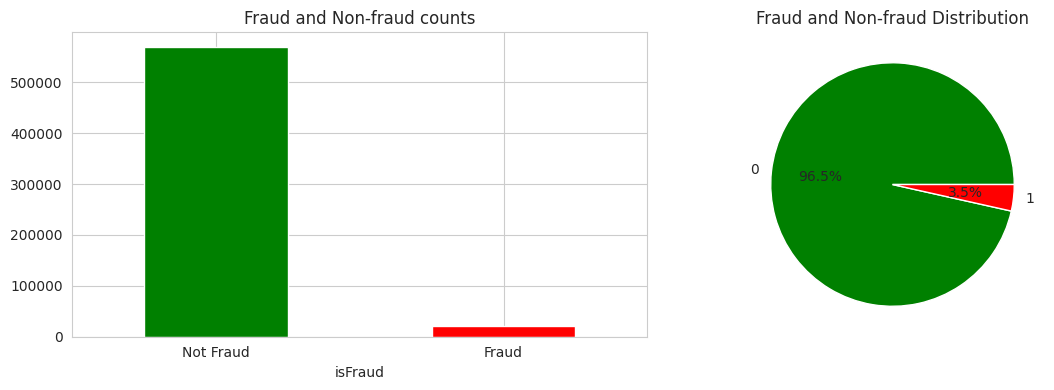

In [10]:

fraud_mean = train['isFraud'].mean()

fraud_cnts = train['isFraud'].value_counts()

print(f"non-fraud: {fraud_cnts[0]:,} ({(1-fraud_mean)*100:.1f}%)")
print(f"Fraud:     {fraud_cnts[1]:,} ({fraud_mean*100:.1f}%)\n")
print(f"fraud/non-fraud: {int((1-fraud_mean)/fraud_mean)} non-fraud")

fig, ax = plt.subplots(1, 2, figsize=(12, 4))
fraud_cnts.plot(kind='bar', ax=ax[0], color=['green', 'red'])
ax[0].set_title('Fraud and Non-fraud counts')
ax[0].set_xticklabels(['Not Fraud', 'Fraud'], rotation=0)
fraud_cnts.plot(kind='pie', ax=ax[1], autopct='%1.1f%%', colors=['green', 'red'])
ax[1].set_title('Fraud and Non-fraud Distribution')
ax[1].set_ylabel('')
plt.tight_layout()
plt.show()

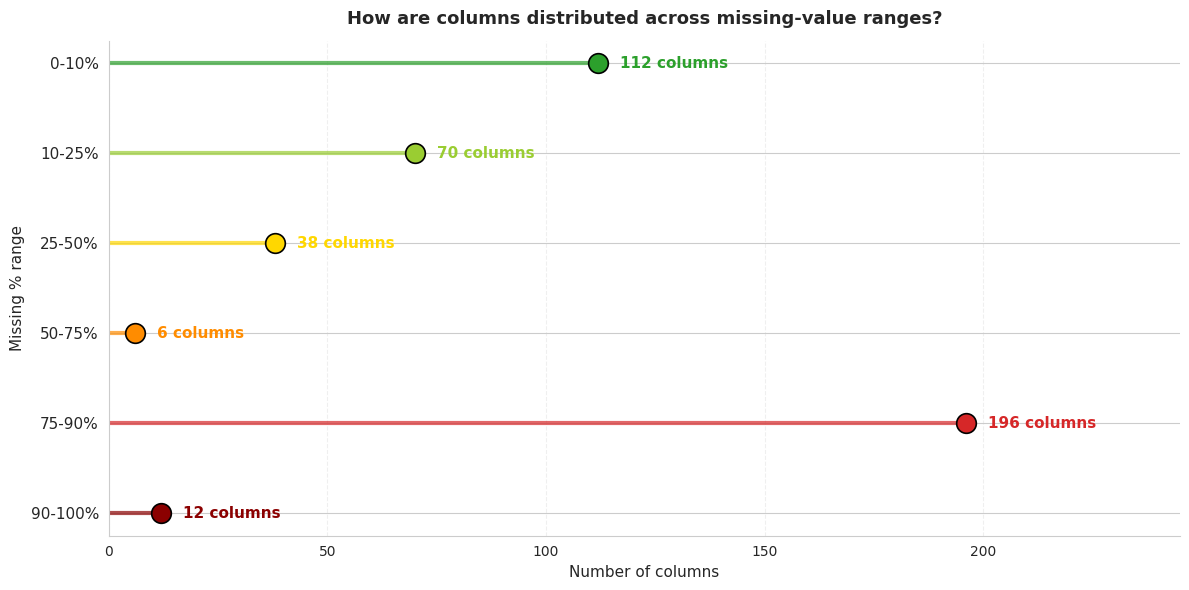

Total columns: 434

Distribution across missing ranges:
  0-10%       112 columns  (25.8% of all columns)
  10-25%       70 columns  (16.1% of all columns)
  25-50%       38 columns  (8.8% of all columns)
  50-75%        6 columns  (1.4% of all columns)
  75-90%      196 columns  (45.2% of all columns)
  90-100%      12 columns  (2.8% of all columns)


In [11]:
import numpy as np
import matplotlib.pyplot as plt


missing_pct = (train.isnull().mean() * 100).sort_values(ascending=False).values
total = len(missing_pct)

fig, ax = plt.subplots(figsize=(12, 6))


bins = [0, 10, 25, 50, 75, 90, 100]
bin_labels = ['0-10%', '10-25%', '25-50%', '50-75%', '75-90%', '90-100%']
bin_counts = [((missing_pct >= bins[i]) & (missing_pct < bins[i+1])).sum() 
              for i in range(len(bins)-1)]


bin_counts[-1] = ((missing_pct >= 90)).sum()

colors = ['#2CA02C', '#9ACD32', '#FFD700', '#FF8C00', '#D62728', '#8B0000']

y_pos = np.arange(len(bin_labels))

for i, (count, color) in enumerate(zip(bin_counts, colors)):
    ax.hlines(y=i, xmin=0, xmax=count, color=color, linewidth=3, alpha=0.7)
    ax.scatter(count, i, color=color, s=200, zorder=5, edgecolor='black', linewidth=1.2)
    ax.text(count + 5, i, f'{count} columns', va='center', fontsize=11, 
            color=color, fontweight='bold')

ax.set_yticks(y_pos)
ax.set_yticklabels(bin_labels, fontsize=11)
ax.set_xlabel('Number of columns', fontsize=11)
ax.set_ylabel('Missing % range', fontsize=11)
ax.set_title('How are columns distributed across missing-value ranges?',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xlim(0, max(bin_counts) * 1.25)
ax.invert_yaxis()
ax.grid(axis='x', alpha=0.3, linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.show()


print(f"Total columns: {total}\n")
print("Distribution across missing ranges:")
for label, count in zip(bin_labels, bin_counts):
    pct = count / total * 100
    print(f"  {label:<10} {count:>4} columns  ({pct:.1f}% of all columns)")

In [12]:
cat_cols = train.select_dtypes(include=['object']).columns.tolist()

cat_summary = pd.DataFrame({
    'column': cat_cols,
    'n_unique': [train[c].nunique() for c in cat_cols],
    'missing_%': [train[c].isnull().mean() * 100 for c in cat_cols]
}).sort_values('n_unique', ascending=False)

print(f"Total categorical columns: {len(cat_cols)}\n")
print(cat_summary.to_string(index=False))

Total categorical columns: 31

       column  n_unique  missing_%
   DeviceInfo      1786  79.905510
        id_33       260  87.589494
        id_31       130  76.245132
        id_30        75  86.865411
R_emaildomain        60  76.751617
P_emaildomain        59  15.994852
    ProductCD         5   0.000000
        card6         4   0.266028
        card4         4   0.267044
        id_34         4  86.824771
        id_15         3  76.126088
           M4         3  47.658753
        id_23         3  99.124699
           M2         2  45.907136
           M1         2  45.907136
        id_12         2  75.576083
           M9         2  58.633115
           M8         2  58.633115
           M7         2  58.635317
           M6         2  28.678836
           M5         2  59.349409
           M3         2  45.907136
        id_27         2  99.124699
        id_28         2  76.127273
        id_29         2  76.127273
        id_16         2  78.098012
        id_35         2 


TransactionAmt stats by class:
               mean   50%         std        max
isFraud                                         
0        134.511665  68.5  239.395078  31937.391
1        149.244779  75.0  232.212163   5191.000


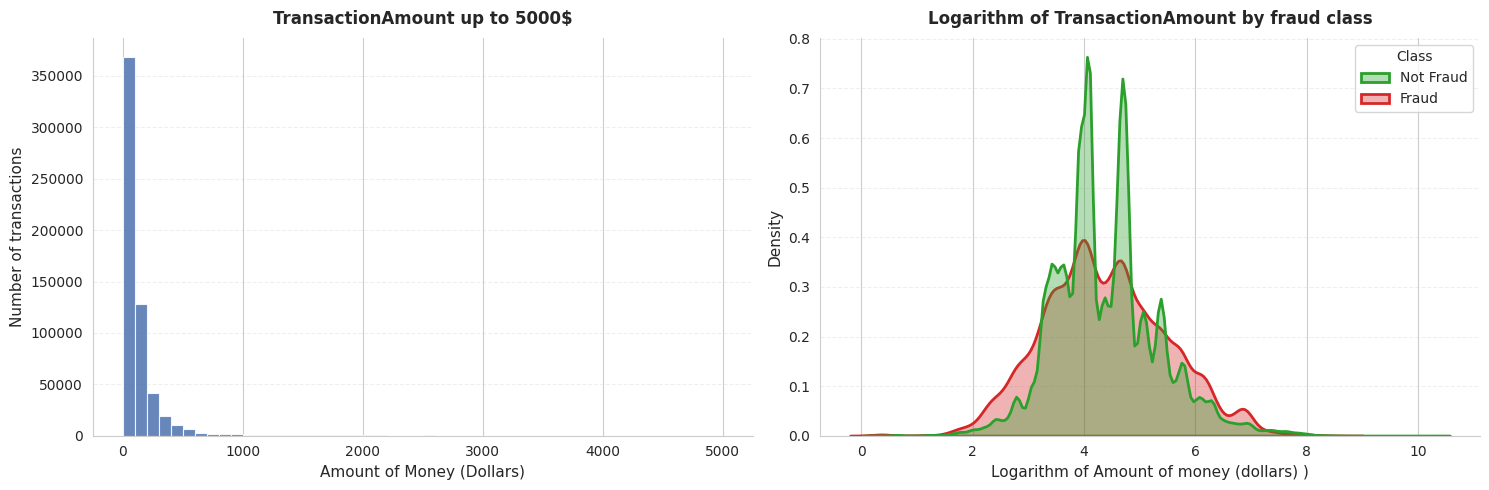

In [13]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


print("\nTransactionAmt stats by class:")
print(train.groupby('isFraud')['TransactionAmt'].describe()[['mean', '50%', 'std', 'max']])

fig, ax = plt.subplots(1, 2, figsize=(15, 5))


ax[0].hist(train['TransactionAmt'].clip(0, 5000), bins=50,
           edgecolor='white', linewidth=0.8, color='#4C72B0', alpha=0.85)
ax[0].set_title('TransactionAmount up to 5000$', fontsize=12, fontweight='bold', pad=10)
ax[0].set_xlabel('Amount of Money (Dollars)', fontsize=11)
ax[0].set_ylabel('Number of transactions', fontsize=11)
ax[0].grid(axis='y', alpha=0.3, linestyle='--')
ax[0].set_axisbelow(True)
ax[0].spines['top'].set_visible(False)
ax[0].spines['right'].set_visible(False)

palette = {0: '#2CA02C', 1: '#D62728'}
sns.kdeplot(
    data=train, x=np.log1p(train['TransactionAmt']),
    hue='isFraud', common_norm=False,
    palette=palette, fill=True, alpha=0.35, linewidth=2,
    ax=ax[1]
)
ax[1].set_title('Logarithm of TransactionAmount by fraud class', fontsize=12, fontweight='bold', pad=10)
ax[1].set_xlabel('Logarithm of Amount of money (dollars) )', fontsize=11)
ax[1].set_ylabel('Density', fontsize=11)
ax[1].grid(axis='y', alpha=0.3, linestyle='--')
ax[1].set_axisbelow(True)
ax[1].spines['top'].set_visible(False)
ax[1].spines['right'].set_visible(False)

# Fix legend labels
legend = ax[1].get_legend()
if legend is not None:
    legend.set_title('Class')
    for text, label in zip(legend.texts, ['Not Fraud', 'Fraud']):
        text.set_text(label)

plt.tight_layout()
plt.show()

In [14]:
# Find categorical columns where fraud rate varies the most across categories
cat_cols = train.select_dtypes(include=['object']).columns.tolist()
results = []
for col in cat_cols:
    grp = train.groupby(col)['isFraud'].agg(['mean', 'count'])
    grp = grp[grp['count'] >= 500]   # ignore tiny groups
    if len(grp) < 2:
        continue
    results.append({
        'column': col,
        'n_unique': train[col].nunique(),
        'n_categories_used': len(grp),
        'min_rate_%': grp['mean'].min() * 100,
        'max_rate_%': grp['mean'].max() * 100,
        'spread_%': (grp['mean'].max() - grp['mean'].min()) * 100,
        'overall_missing_%': train[col].isnull().mean() * 100,
    })
ranked = pd.DataFrame(results).sort_values('spread_%', ascending=False)
print(ranked.round(2).to_string(index=False))

       column  n_unique  n_categories_used  min_rate_%  max_rate_%  spread_%  overall_missing_%
        id_31       130                 31        0.15       21.84     21.69              76.25
P_emaildomain        59                 24        0.30       18.96     18.66              15.99
R_emaildomain        60                 15        0.00       16.51     16.51              76.75
        id_33       260                 20        0.75       13.73     12.98              87.59
        id_30        75                 26        1.24       12.17     10.93              86.87
    ProductCD         5                  5        2.04       11.69      9.65               0.00
   DeviceInfo      1786                  7        1.29       10.93      9.64              79.91
           M4         3                  3        2.71       11.37      8.67              47.66
        id_23         3                  3        5.58       13.73      8.14              99.12
        id_35         2                 

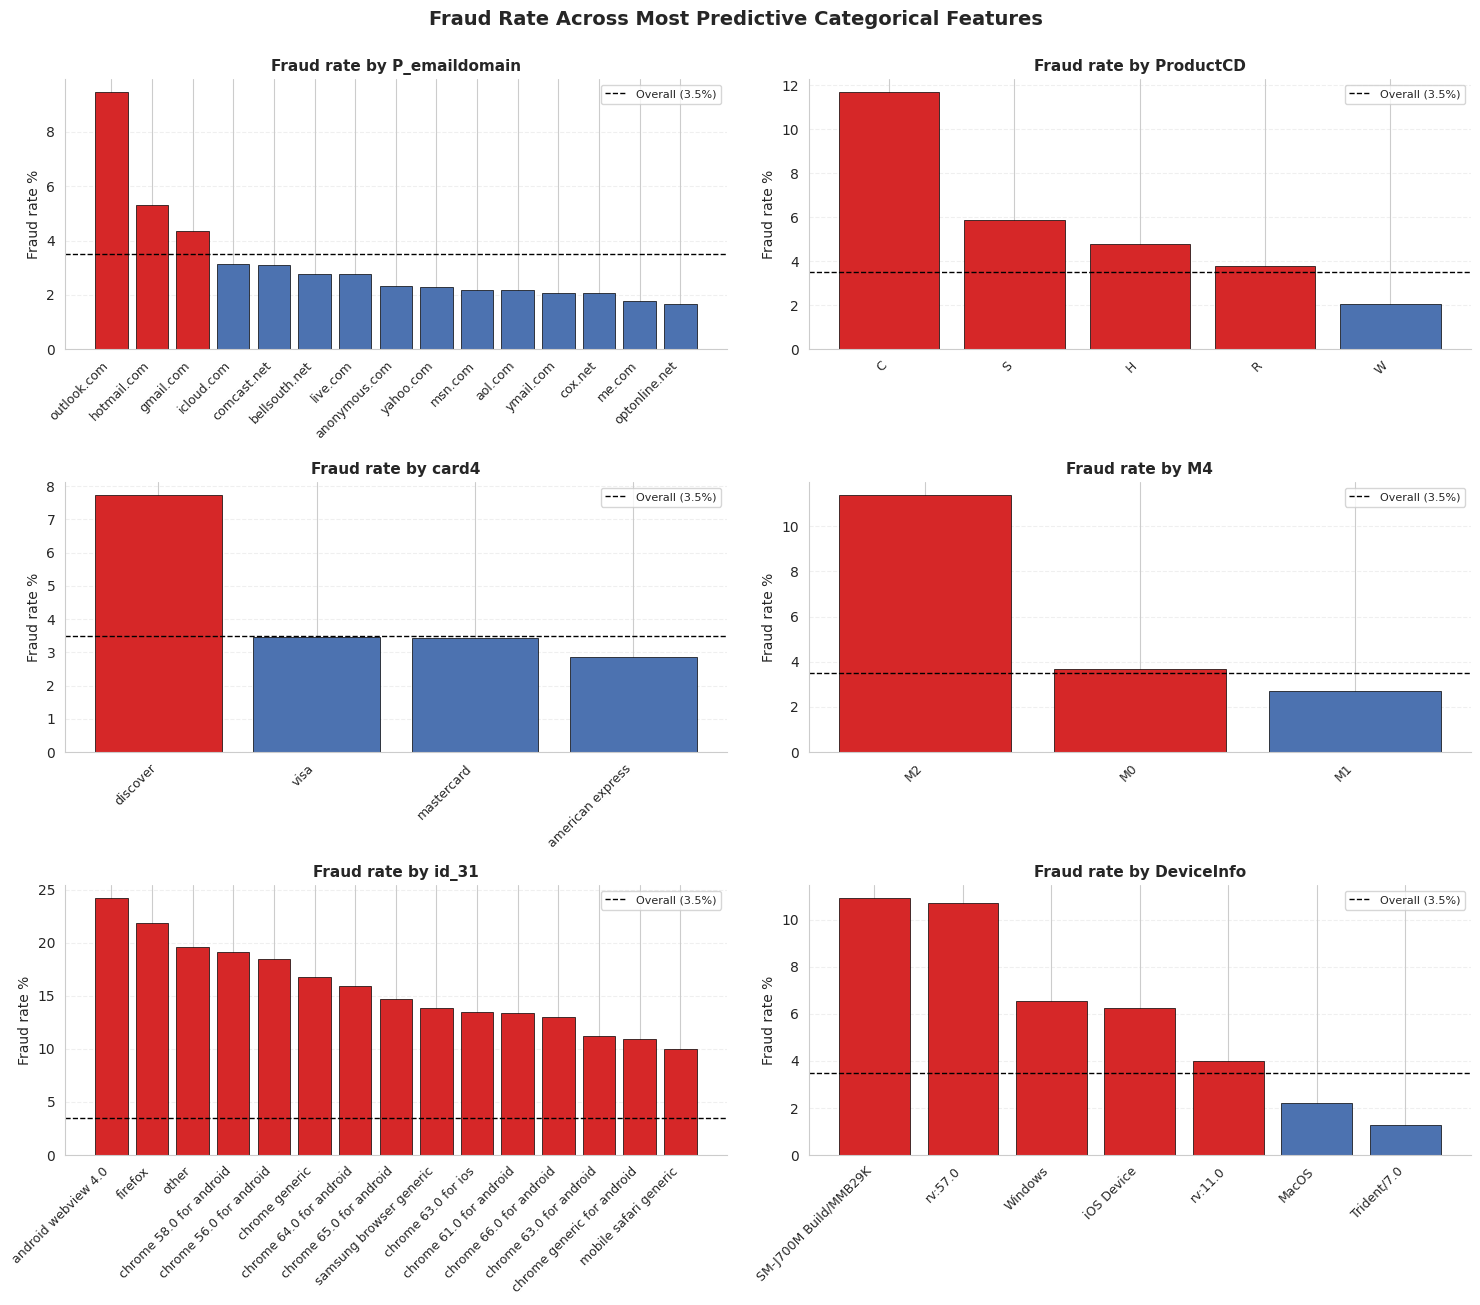

In [15]:
import matplotlib.pyplot as plt
import numpy as np

overall_rate = train['isFraud'].mean() * 100

def plot_fraud_rate(ax, col, top_n=None, min_count=500):
    """Plot fraud rate per category for one column."""
    grp = train.groupby(col)['isFraud'].agg(['mean', 'count'])
    grp = grp[grp['count'] >= min_count] 
    grp['fraud_rate'] = grp['mean'] * 100
    grp = grp.sort_values('fraud_rate', ascending=False)
    if top_n:
        grp = grp.head(top_n)

    colors = ['#D62728' if r > overall_rate else '#4C72B0' for r in grp['fraud_rate']]
    ax.bar(range(len(grp)), grp['fraud_rate'], color=colors, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(grp)))
    ax.set_xticklabels(grp.index, rotation=45, ha='right', fontsize=9)
    ax.axhline(overall_rate, color='black', linestyle='--', linewidth=1,
               label=f'Overall ({overall_rate:.1f}%)')
    ax.set_title(f'Fraud rate by {col}', fontsize=11, fontweight='bold')
    ax.set_ylabel('Fraud rate %')
    ax.legend(fontsize=8)
    ax.grid(axis='y', alpha=0.3, linestyle='--')
    ax.set_axisbelow(True)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


fig, axes = plt.subplots(3, 2, figsize=(15, 13))
fig.suptitle('Fraud Rate Across Most Predictive Categorical Features',
             fontsize=14, fontweight='bold', y=1.00)

# Row 1: high signal + mostly present
plot_fraud_rate(axes[0, 0], 'P_emaildomain', top_n=15, min_count=1000)
plot_fraud_rate(axes[0, 1], 'ProductCD',     min_count=500)

# Row 2: card brand + match column
plot_fraud_rate(axes[1, 0], 'card4',         min_count=500)
plot_fraud_rate(axes[1, 1], 'M4',            min_count=500)

# Row 3: strong-when-present identity signals
plot_fraud_rate(axes[2, 0], 'id_31',         top_n=15, min_count=200)
plot_fraud_rate(axes[2, 1], 'DeviceInfo',    top_n=10, min_count=500)

plt.tight_layout()
plt.show()

In [16]:
train_days = train['TransactionDT'] / (3600 * 24)
test_days  = test['TransactionDT']  / (3600 * 24)

print(f"Train: day {train_days.min():.0f} to day {train_days.max():.0f}  ({train_days.max() - train_days.min():.0f} days)")
print(f"Test:  day {test_days.min():.0f} to day {test_days.max():.0f}  ({test_days.max() - test_days.min():.0f} days)")
print(f"Gap between train end and test start: {test_days.min() - train_days.max():.1f} days")

Train: day 1 to day 183  (182 days)
Test:  day 213 to day 396  (183 days)
Gap between train end and test start: 30.0 days


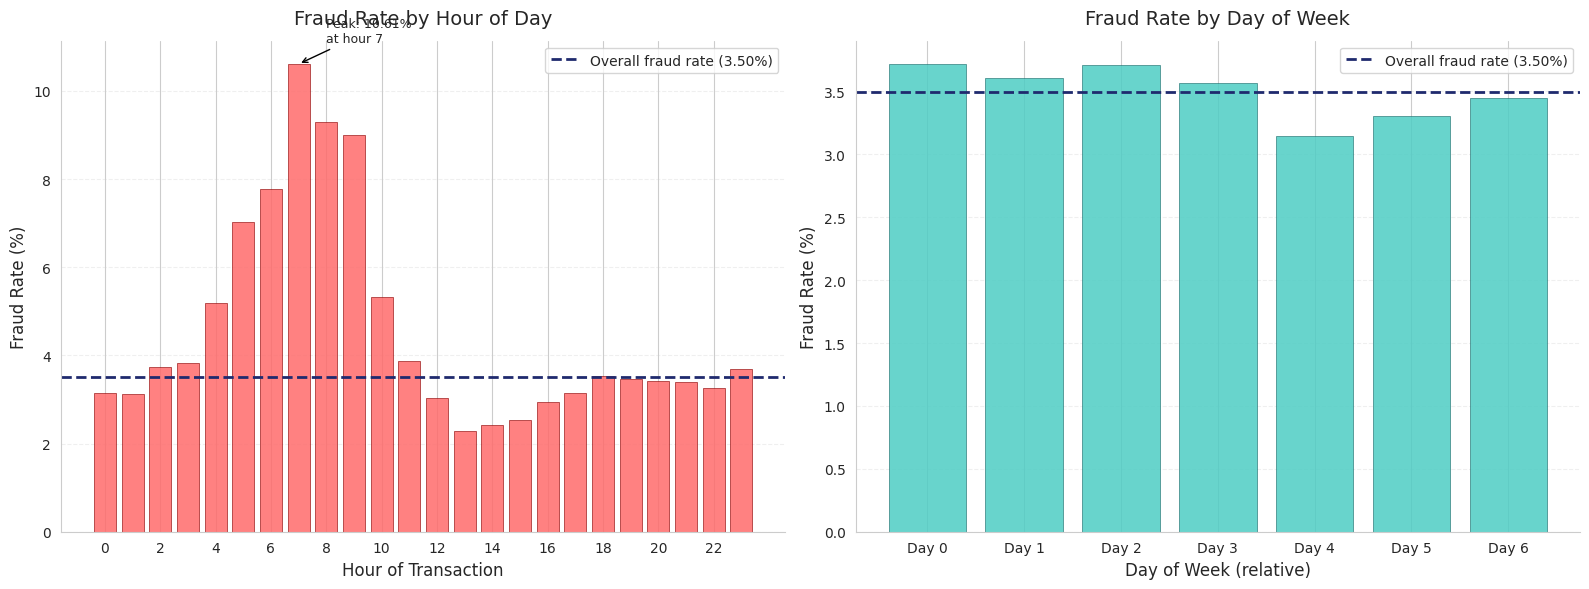


Fraud rate range by hour: 2.29% to 10.61%
Fraud rate range by day:  3.15% to 3.72%
Overall fraud rate:       3.50%


In [17]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np


PATH = "/kaggle/input/competitions/ieee-fraud-detection/"
train_tx = pd.read_csv(PATH + "train_transaction.csv")


train_tx['hour_of_transaction'] = (train_tx['TransactionDT'] // 3600) % 24
train_tx['day_of_transaction'] = (train_tx['TransactionDT'] // 86400) % 7


hour_stats = train_tx.groupby('hour_of_transaction').agg(
    fraud_rate=('isFraud', 'mean'),
    n_transactions=('isFraud', 'size'),
).reset_index()


day_stats = train_tx.groupby('day_of_transaction').agg(
    fraud_rate=('isFraud', 'mean'),
    n_transactions=('isFraud', 'size'),
).reset_index()

overall_fraud_rate = train_tx['isFraud'].mean()



fig, axes = plt.subplots(1, 2, figsize=(16, 6))


ax = axes[0]
bars = ax.bar(hour_stats['hour_of_transaction'], hour_stats['fraud_rate'] * 100,
              color='#FF6B6B', alpha=0.85, edgecolor='#8B0000', linewidth=0.5)
ax.axhline(y=overall_fraud_rate * 100, color='#1F2A6E', linestyle='--', linewidth=2,
           label=f'Overall fraud rate ({overall_fraud_rate*100:.2f}%)')
ax.set_xlabel('Hour of Transaction', fontsize=12)
ax.set_ylabel('Fraud Rate (%)', fontsize=12)
ax.set_title('Fraud Rate by Hour of Day', fontsize=14, pad=12)
ax.set_xticks(range(0, 24, 2))
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=10)

# Highlight the spread
max_hour = hour_stats.loc[hour_stats['fraud_rate'].idxmax()]
min_hour = hour_stats.loc[hour_stats['fraud_rate'].idxmin()]
ax.annotate(f"Peak: {max_hour['fraud_rate']*100:.2f}%\nat hour {int(max_hour['hour_of_transaction'])}",
            xy=(max_hour['hour_of_transaction'], max_hour['fraud_rate']*100),
            xytext=(max_hour['hour_of_transaction']+1, max_hour['fraud_rate']*100+0.5),
            fontsize=9, ha='left',
            arrowprops=dict(arrowstyle='->', color='black', lw=1))


# Day of week
ax = axes[1]
day_labels = ['Day 0', 'Day 1', 'Day 2', 'Day 3', 'Day 4', 'Day 5', 'Day 6']
bars = ax.bar(day_stats['day_of_transaction'], day_stats['fraud_rate'] * 100,
              color='#4ECDC4', alpha=0.85, edgecolor='#1A6B6B', linewidth=0.5)
ax.axhline(y=overall_fraud_rate * 100, color='#1F2A6E', linestyle='--', linewidth=2,
           label=f'Overall fraud rate ({overall_fraud_rate*100:.2f}%)')
ax.set_xlabel('Day of Week (relative)', fontsize=12)
ax.set_ylabel('Fraud Rate (%)', fontsize=12)
ax.set_title('Fraud Rate by Day of Week', fontsize=14, pad=12)
ax.set_xticks(range(7))
ax.set_xticklabels(day_labels)
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=10)

plt.tight_layout()
plt.savefig('time_fraud_rate.png', dpi=120, bbox_inches='tight')
plt.show()


print(f"\nFraud rate range by hour: {hour_stats['fraud_rate'].min()*100:.2f}% to {hour_stats['fraud_rate'].max()*100:.2f}%")
print(f"Fraud rate range by day:  {day_stats['fraud_rate'].min()*100:.2f}% to {day_stats['fraud_rate'].max()*100:.2f}%")
print(f"Overall fraud rate:       {overall_fraud_rate*100:.2f}%")

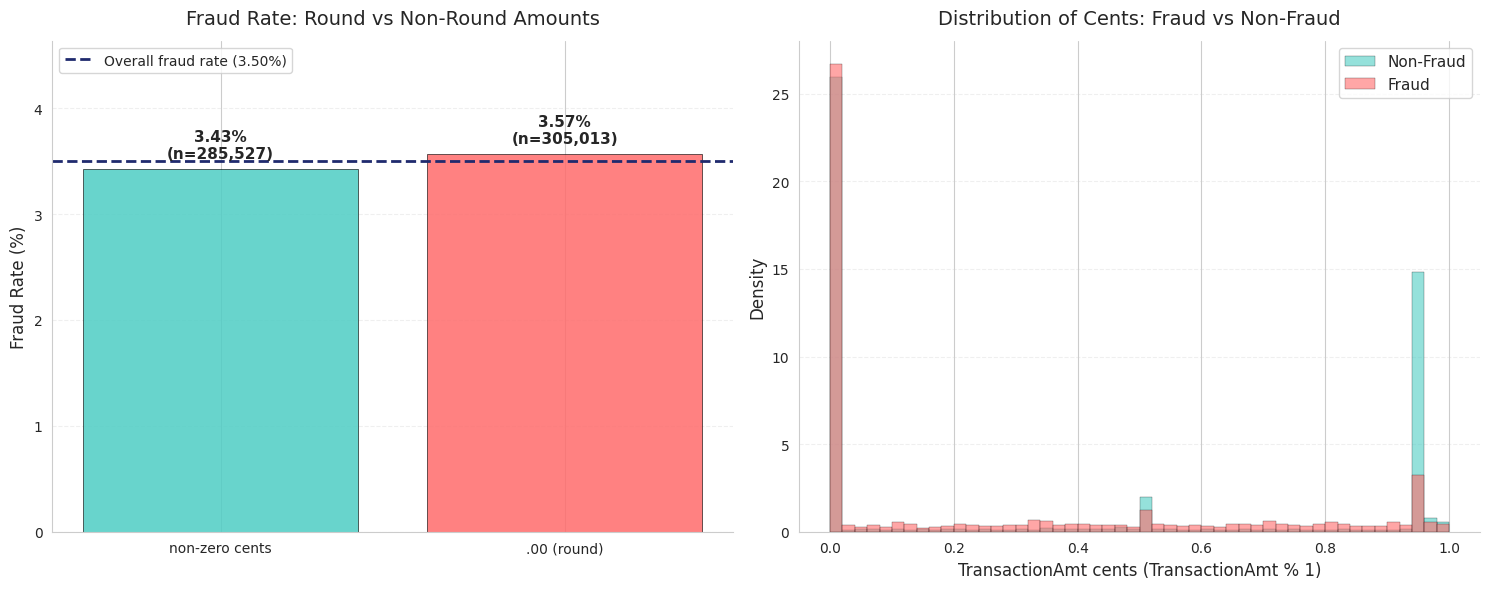


=== Summary ===
Round amounts (.00):     fraud rate = 3.57%, n = 305,013
Non-round amounts:       fraud rate = 3.43%, n = 285,527
Overall fraud rate:      3.50%
Ratio (round / non-round): 1.04x


In [18]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

PATH = "/kaggle/input/competitions/ieee-fraud-detection/"
train_tx = pd.read_csv(PATH + "train_transaction.csv")


train_tx['TransactionAmt_cents'] = train_tx['TransactionAmt'] % 1


train_tx['is_round_amount'] = (train_tx['TransactionAmt_cents'] == 0)


round_stats = train_tx.groupby('is_round_amount').agg(
    fraud_rate=('isFraud', 'mean'),
    n_transactions=('isFraud', 'size'),
).reset_index()
round_stats['label'] = round_stats['is_round_amount'].map({
    True:  '.00 (round)',
    False: 'non-zero cents',
})

overall_fraud_rate = train_tx['isFraud'].mean()



fig, axes = plt.subplots(1, 2, figsize=(15, 6))


ax = axes[0]
colors = ['#4ECDC4', '#FF6B6B']
bars = ax.bar(round_stats['label'], round_stats['fraud_rate'] * 100,
              color=colors, alpha=0.85, edgecolor='black', linewidth=0.5)


for bar, rate, n in zip(bars, round_stats['fraud_rate'], round_stats['n_transactions']):
    ax.text(bar.get_x() + bar.get_width()/2,
            bar.get_height() + 0.1,
            f"{rate*100:.2f}%\n(n={n:,})",
            ha='center', fontsize=11, fontweight='bold')

ax.axhline(y=overall_fraud_rate * 100, color='#1F2A6E', linestyle='--', linewidth=2,
           label=f'Overall fraud rate ({overall_fraud_rate*100:.2f}%)')
ax.set_ylabel('Fraud Rate (%)', fontsize=12)
ax.set_title('Fraud Rate: Round vs Non-Round Amounts', fontsize=14, pad=12)
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper left', fontsize=10)
ax.set_ylim(0, max(round_stats['fraud_rate'])*100 * 1.3)



ax = axes[1]

bins = np.linspace(0, 1, 51) 

ax.hist(train_tx[train_tx['isFraud']==0]['TransactionAmt_cents'],
        bins=bins, alpha=0.6, label='Non-Fraud', color='#4ECDC4',
        density=True, edgecolor='black', linewidth=0.3)
ax.hist(train_tx[train_tx['isFraud']==1]['TransactionAmt_cents'],
        bins=bins, alpha=0.6, label='Fraud', color='#FF6B6B',
        density=True, edgecolor='black', linewidth=0.3)

ax.set_xlabel('TransactionAmt cents (TransactionAmt % 1)', fontsize=12)
ax.set_ylabel('Density', fontsize=12)
ax.set_title('Distribution of Cents: Fraud vs Non-Fraud', fontsize=14, pad=12)
ax.grid(alpha=0.3, axis='y', linestyle='--')
ax.set_axisbelow(True)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.legend(loc='upper right', fontsize=11)

plt.tight_layout()
plt.savefig('cents_fraud.png', dpi=120, bbox_inches='tight')
plt.show()



fraud_round = round_stats[round_stats['is_round_amount']==True]['fraud_rate'].values[0]
fraud_nonround = round_stats[round_stats['is_round_amount']==False]['fraud_rate'].values[0]

print(f"\n Summary")
print(f"Round amounts (.00):     fraud rate = {fraud_round*100:.2f}%, n = {round_stats[round_stats['is_round_amount']==True]['n_transactions'].values[0]:,}")
print(f"Non-round amounts:       fraud rate = {fraud_nonround*100:.2f}%, n = {round_stats[round_stats['is_round_amount']==False]['n_transactions'].values[0]:,}")
print(f"Overall fraud rate:      {overall_fraud_rate*100:.2f}%")
print(f"Ratio (round / non-round): {fraud_round/fraud_nonround:.2f}x")

In [19]:
train.describe()

,TransactionID,isFraud,TransactionDT,TransactionAmt,card1,card2,card3,card5,addr1,addr2,dist1,dist2,C1,C2,C3,C4,C5,C6,C7,C8,C9,C10,C11,C12,C13,C14,D1,D2,D3,D4,D5,D6,D7,D8,D9,D10,D11,D12,D13,D14,D15,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V313,V314,V315,V316,V317,V318,V319,V320,V321,V322,V323,V324,V325,V326,V327,V328,V329,V330,V331,V332,V333,V334,V335,V336,V337,V338,V339,id_01,id_02,id_03,id_04,id_05,id_06,id_07,id_08,id_09,id_10,id_11,id_13,id_14,id_17,id_18,id_19,id_20,id_21,id_22,id_24,id_25,id_26,id_32
count,5.905400e+05,590540.000000,5.905400e+05,590540.000000,590540.000000,581607.000000,588975.000000,586281.000000,524834.000000,524834.000000,238269.000000,37627.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,590540.000000,589271.000000,309743.000000,327662.000000,421618.000000,280699.000000,73187.000000,38917.000000,74926.000000,74926.000000,514518.000000,311253.000000,64717.000000,61952.000000,62187.000000,501427.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,311253.000000,...,589271.000000,589271.000000,589271.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,590528.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.000000,82351.00000,82351.000000,82351.000000,82351.000000,82351.000000,144233.000000,140872.000000,66324.000000,66324.000000,136865.000000,136865.000000,5155.000000,5155.000000,74926.000000,74926.000000,140978.000000,127320.000000,80044.000000,139369.000000,45113.000000,139318.000000,139261.000000,5159.000000,5169.000000,4747.000000,5132.000000,5163.000000,77586.000000
mean,3.282270e+06,0.034990,7.372311e+06,135.027176,9898.734658,362.555488,153.194925,199.278897,290.733794,86.800630,118.502180,231.855423,14.092458,15.269734,0.005644,4.092185,5.571526,9.071082,2.848478,5.144574,4.480240,5.240343,10.241521,4.076227,32.539918,8.295215,94.347568,169.563231,28.343348,140.002441,42.335965,69.805717,41.638950,146.058108,0.561057,123.982137,146.621465,54.037533,17.901295,57.724444,163.744579,0.999945,1.045204,1.078075,0.846456,0.876991,1.045686,1.072870,1.027704,1.041529,...,21.351473,43.319174,26.806977,109.818544,247.606741,162.153398,18.372476,42.073133,28.326584,6.220289,13.103775,9.184612,0.058494,0.851040,0.296633,0.336790,1.312844,0.775874,721.741883,1375.783644,1014.622782,9.807015,59.16455,28.530903,55.352422,151.160542,100.700882,-10.170502,174716.584708,0.060189,-0.058938,1.615585,-6.698710,13.285354,-38.600388,0.091023,-0.301124,99.745325,48.053071,-344.507146,189.451377,14.237337,353.128174,403.882666,368.269820,16.002708,12.800927,329.608924,149.070308,26.508597
std,1.704744e+05,0.183755,4.617224e+06,239.162522,4901.170153,157.793246,11.336444,41.244453,101.741072,2.690623,371.872026,529.053494,133.569018,154.668899,0.150536,68.848459,25.786976,71.508467,61.727304,95.378574,16.674897,95.581443,94.336292,86.666218,129.364844,49.544262,157.660387,177.315865,62.384721,191.096774,89.000144,143.669253,99.743264,231.663840,0.316880,182.615225,186.042622,124.274558,67.614425,136.312450,202.726660,0.007390,0.240133,0.320890,0.440053,0.475902,0.239385,0.304779,0.186069,0.226339,...,95.902970,173.619028,116.853222,2270.033202,3980.042828,2793.343636,332.304848,473.499307,382.053171,56.022561,106.739813,73.627893,0.304415,3.950295,1.364356,1.580144,8.769083,4.727971,6217.223583,11169.275702,7955.735482,243.861391,387.62948,274.576920,668.486833,1095.034387,814.946722,14.347949,159651.816856,0.598231,0.701015,5.249856,16.491104,11.384207,26.084899,0.983842,2.789446,1.127602,11.774858,93.695502,30.375360,1.561302,141.095343,152.160327,198.847038,6.897665,2.372447,97.461089,32.101995,3.737502
min,2.987000e+06,0.000000,8.640000e+04,0.251000,1000.000000,100.000000,100.000000